In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Kolom = 225, Baris = 225


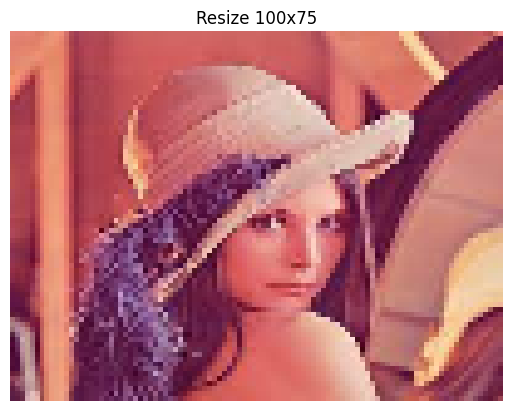

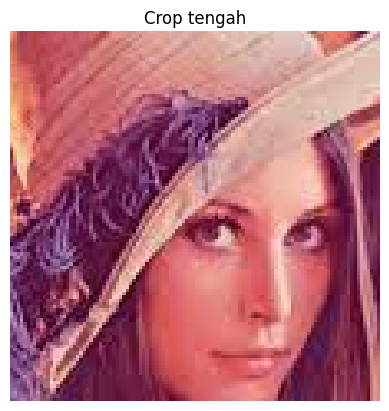

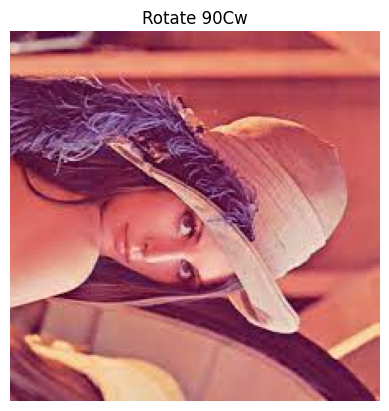

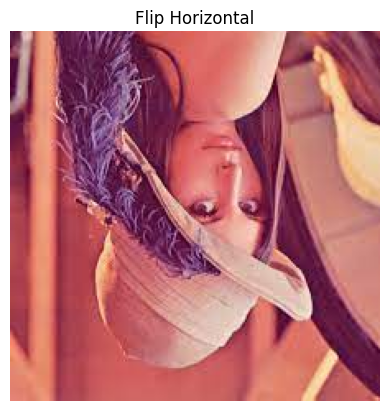

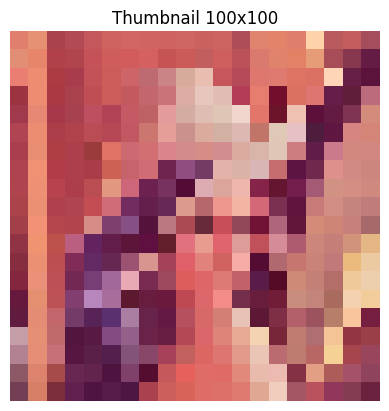

In [8]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


img = cv2.imread("/content/drive/MyDrive/Computer Vision/dataset/lena.jpg")
assert img is not None, "Gambar tidak ditemukan. Pastikan file lena.jpg ada()"
h,w = img.shape[:2]
print("Kolom = {}, Baris = {}".format(h,w))

#Resize
ukuran = cv2.resize(img, (100,75))

#crop
ch, cw = h//4, w//4
crop = img[ch:ch+h//2, cw:cw+w//2]

#Rotate 90cw
rotasi = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
rotate = cv2.resize(rotasi, (w,h))

#Flip
flip = cv2.flip(img,1)
flip = cv2.flip(img, 0)

def show(title, im):
  plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
  plt.title(title)
  plt.axis('off')
  plt.show()

for t,im in ([("Resize 100x75", ukuran), ("Crop tengah", crop), ("Rotate 90Cw", rotate), ("Flip Horizontal", flip)]):
  show(t, im)

#Thumbnail Generator
def thumbnail_generator(image, size=(20,20)):
  return cv2.resize(image,size)

thumb = thumbnail_generator(img,(20,20))
show("Thumbnail 100x100", thumb)

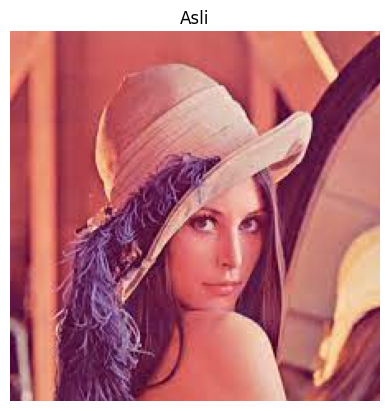

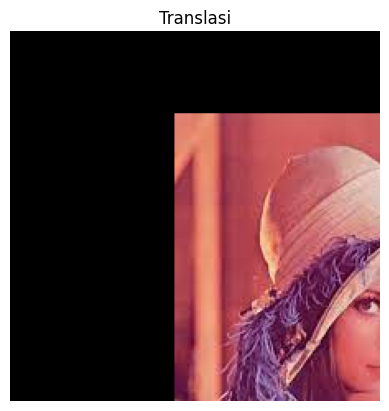

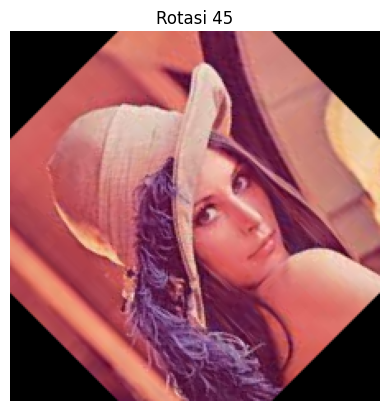

In [13]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

path = "/content/drive/MyDrive/Computer Vision/dataset/lena.jpg" # Changed path to a specific image file
img = cv2.imread(path)

if img is None:
  raise ValueError("Gambar tidak ditemukan. Periksa Path!")

#Ukuran gambar
tinggi, lebar = img.shape[:2]

# Translasi
tx, ty = 100, 50
matriks_translasi = np.float32([[1, 0, tx], [0, 1, ty]])
hasil_translasi = cv2.warpAffine(img, matriks_translasi, (lebar, tinggi))

#Rotasi
sudut = 45
pusat = (lebar // 2, tinggi // 2)
matriks_rotasi = cv2.getRotationMatrix2D(pusat, sudut, 1)
hasil_rotasi = cv2.warpAffine(img, matriks_rotasi, (lebar, tinggi))

#skala
hasil_skala_besar = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)
hasil_skala_kecil = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

#Flip
flip_horizontal = cv2.flip(img, 1)
flip_vertikal = cv2.flip(img, 0)
flip_both = cv2.flip(img, -1)

#Affine transform
#titik sumber (3 titik pada gambar asli)
pts1 = np.float32([[50,50], [200,50], [50,200]])
#titik tujuan
pts2 = np.float32([[10,100], [200,50], [100,250]])
matriks_affine = cv2.getAffineTransform(pts1, pts2)
hasil_affine = cv2.warpAffine(img, matriks_affine, (lebar, tinggi))

#prespektif
pts1 = np.float32([[100,100], [400,100], [100,400], [400,400]])
pts2 = np.float32([[50,150], [450,100], [150,450], [400,400]])
matriks_prespektif = cv2.getPerspectiveTransform(pts1, pts2)
hasil_prespektif = cv2.warpPerspective(img, matriks_prespektif, (lebar, tinggi))

def show(title, im):
  plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); plt.title(title); plt.axis('off'); plt.show()

#tampilkan semua

show("Asli", img)
show("Translasi", hasil_translasi)
show("Rotasi 45", hasil_rotasi)